In [111]:
# importing the packages:
from dataclasses import dataclass
import os
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional
from tqdm.notebook import tqdm
from pathlib import Path

# survival
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis

# modeling utils
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# univariate cox (optional)
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.table import Table


import math
from scipy.stats import norm
from scipy.stats import zscore
from scipy.stats import fisher_exact, chi2_contingency, mannwhitneyu
import scipy.stats
import sys

import warnings
warnings.filterwarnings("ignore")
import openpyxl



In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Reading the dataframe:*

In [ ]:
cutoff = 2000

In [4]:
print('reading the main dataframe:')
d35_input_full = pd.read_excel(f'/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/DATA/patient_data_excels/d35/FinalPopulationPercentages_ClinicalInfo_3000threshold_2026_03_09.xlsx')
d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]

PERCENT_FEATURES = [c for c in d35_input_full_copy.columns if ' of ' in c]
myeloid_endings = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid']
myeloid_endings_and_CD45pos = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid', ' of CD45pos']
myeloid_child = set(element.split(' of ')[0] for element in PERCENT_FEATURES if element.endswith(tuple(myeloid_endings)))
myeloid_params_exclude = [element for element in PERCENT_FEATURES if element.startswith(tuple(myeloid_child)) and element.endswith(tuple(myeloid_endings_and_CD45pos))]
PERCENT_FEATURES = list(set(PERCENT_FEATURES) - set(myeloid_params_exclude))

PERCENT_FEATURES_renamer = {}
to_rename = [element for element in PERCENT_FEATURES if 'LowLevel' in element]
for element in to_rename:
    PERCENT_FEATURES_renamer[element] = element.replace('LowLevel ', 'High Resolution ')
d35_input_full_copy = d35_input_full_copy.rename(columns = PERCENT_FEATURES_renamer)
PERCENT_FEATURES = [element.replace('LowLevel ', 'High Resolution ') for element in PERCENT_FEATURES]

RATIO_FEATURES   = [c for c in d35_input_full_copy.columns if '-to-' in c]
OUTCOME_COLS = {
    "RFS": {"time": 'Time_to_Relapse_from_TPL', "event": 'Relapse_Present_1_NotObserved_0'},
    "OS":  {"time": 'Time_to_Death_from_TPL',  "event": 'Death_Present_1_NotObserved_0'},
    "aGVHD": {"time": "Time_to_aGVHD", "event": "aGVHD_grading_by_Katja"},
    "cGVHD": {"time": "Time_to_cGVHD", "event": "cGVHD_grading_by_Katja"},
}

d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = round(d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'], 0)
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'].astype("Int64")
d35_input_full_copy['Cutoff_Plus_SamplingDay'] = cutoff + d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

# version with horizoning by a sum of cutoff + sampling day & then landmarking (X days post sampling)
d35_input_full_copy[OUTCOME_COLS['RFS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['RFS']['event']])
d35_input_full_copy[OUTCOME_COLS['RFS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['RFS']['time']])
d35_input_full_copy[OUTCOME_COLS['OS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['OS']['event']])
d35_input_full_copy[OUTCOME_COLS['OS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['OS']['time']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']])

# version with horizoning first & then landmarking (X days post TPL)
# d35_input_full_copy[OUTCOME_COLS['RFS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['RFS']['event']])
# d35_input_full_copy[OUTCOME_COLS['RFS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['RFS']['time']])
# d35_input_full_copy[OUTCOME_COLS['OS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['OS']['event']])
# d35_input_full_copy[OUTCOME_COLS['OS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['OS']['time']])
# d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']])
# d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']])
# d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']])
# d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']])



d35_input_full_copy['Relapse_Present_1_NotObserved_0'] = d35_input_full_copy['Relapse_Present_1_NotObserved_0'].astype("Int64")
d35_input_full_copy['aGVHD_grading_by_Katja'] = d35_input_full_copy['aGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['cGVHD_grading_by_Katja'] = d35_input_full_copy['cGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['MAX_FOLLOW_UP'] = d35_input_full_copy[['Time_to_aGVHD', 'Time_to_cGVHD',
                                                            'Time_to_Relapse_from_TPL','Time_to_Death_from_TPL']].max(axis = 1)


d35_input_full_copy['Time_to_Death_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_Relapse_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_aGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
# only 65 patients (40 in VC and 25 in OC)
d35_input_full_copy['Time_to_cGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['MAX_FOLLOW_UP'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

reading the main dataframe:


*Preparing the metadata columns:*

In [5]:
df_multivariate = d35_input_full_copy.copy()
age_cutoff = 55
df_multivariate[f'Age(>{age_cutoff})'] = np.where(df_multivariate['Age'] > age_cutoff, 1, 0)
age_cutoff = 60
df_multivariate[f'Age(>{age_cutoff})'] = np.where(df_multivariate['Age'] > age_cutoff, 1, 0)
df_multivariate['Age_10y'] = pd.cut(df_multivariate['Age'],
                                    bins=range(0, 101, 10),
                                    labels=[i for i in range(0, 100, 10)],
                                    include_lowest=True)

df_multivariate['MHC_Mismatch_D/R(MM=1)'] = np.where(df_multivariate['MHC_Mismatch_between_Donor&Recipient'] == 'nein', 0, 1)
df_multivariate['ELN_Score(3)'] = np.where(df_multivariate['ELN_Score'] == 3, 1, 0)
df_multivariate['Sex_Recipient(M=1)'] = np.where(df_multivariate['Sex_Recipient'] == 'Male', 1, 0) # Male = 0, Female = 1

df_multivariate['Disease_Score(2)'] = np.where(df_multivariate['Disease_Score'] == 2, 1, 0)
df_multivariate['CMV_Status_R(+)'] = np.where(df_multivariate['CMV_Status_Recipient'] == 'neg', 0, 1)
df_multivariate['CMV_Status_D/R(+/+)'] = np.where((df_multivariate['CMV_Status_Recipient'] == 'pos') & (df_multivariate['CMV_Status_Donor'] == 'pos'), 1, 0)

In [6]:
age_cutoff = 60
clin_var_setup_dict = {
    # f'Age55': [f'Age(>55)'],
    # f'Age60': [f'Age(>60)'],
    # 'Age_10y': ['Age_10y'],
    # 'SexRec': ['Sex_Recipient(M=1)'],
    # 'MHCMM': ['MHC_Mismatch_D/R(MM=1)'],
    # 'ELNScore3': ['ELN_Score(3)'],
    # 'DiseaseScore2': ['Disease_Score(2)'],
    # 'CMVRec': ['CMV_Status_R(+)'],
    # 'CMVRecDon': ['CMV_Status_D/R(+/+)'],
    # 'EBMTRICMAC': ['EBMT_NMA0_RIC1_MAC2'],
    

    # f'NoClinVars': ['GvLhi_GvHDlo'],
    # f'Age{age_cutoff}_SexRec_MHCMM_ELNScore3': ['GvLhi_GvHDlo', f'Age(>{age_cutoff})','Sex_Recipient(M=1)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)'],
    f'Age{age_cutoff}_SexRec_MHCMM_ELNScore3_CMVRec': ['GvLhi_GvHDlo', f'Age(>{age_cutoff})','Sex_Recipient(M=1)','CMV_Status_R(+)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)'],
    # f'Age{age_cutoff}_SexRec_MHCMM_ELNScore3_CMVRec_EBMTRICMAC': ['GvLhi_GvHDlo', f'Age(>{age_cutoff})','Sex_Recipient(M=1)','CMV_Status_R(+)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)','EBMT_NMA0_RIC1_MAC2'],
    # f'Age{age_cutoff}_SexRec_MHCMM_ELNScore3_DiseaseScore2_CMVRec_EBMTRICMAC': ['GvLhi_GvHDlo', f'Age(>{age_cutoff})','Sex_Recipient(M=1)','CMV_Status_R(+)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)','Disease_Score(2)','EBMT_NMA0_RIC1_MAC2'],

    # f'NoScore_Age{age_cutoff}_SexRec_MHCMM_ELNScore3': [f'Age(>{age_cutoff})','Sex_Recipient(M=1)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)'],
    # f'NoScore_Age{age_cutoff}_MHCMM_ELNScore3_DiseaseScore': [f'Age(>{age_cutoff})','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)','Disease_Score(2)'],
    # f'NoScore_Age{age_cutoff}_SexRec_MHCMM_ELNScore3_DiseaseScore2_CMVRec': [f'Age(>{age_cutoff})','Sex_Recipient(M=1)','CMV_Status_R(+)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)','Disease_Score(2)'],
    # f'NoScore_Age{age_cutoff}_SexRec_MHCMM_ELNScore3_CMVRec': [f'Age(>{age_cutoff})','Sex_Recipient(M=1)','CMV_Status_R(+)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)'],
    # f'NoScore_Age{age_cutoff}_SexRec_MHCMM_ELNScore3_CMVRec_EBMTRICMAC': [f'Age(>{age_cutoff})','Sex_Recipient(M=1)','CMV_Status_R(+)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)','EBMT_NMA0_RIC1_MAC2'],
    # f'NoScore_Age{age_cutoff}_SexRec_MHCMM_ELNScore3_DiseaseScore2_CMVRec_EBMTRICMAC': [f'Age(>{age_cutoff})','Sex_Recipient(M=1)','CMV_Status_R(+)','MHC_Mismatch_D/R(MM=1)','ELN_Score(3)','Disease_Score(2)','EBMT_NMA0_RIC1_MAC2'],
}

*Setting up the score:*

In [7]:
score_name = 'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score'
# 'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score'
# 'CD8TEMGeneral_CD4TCM_CD56dimNK_Score'
# 'CD8TEMGeneral_CD4TCM_HighResCD56dimNK_Score'
# 'CD8TEMGeneral_CD4TCMNVratio_CD56dimNK_Score'
# 'CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score'

if score_name == 'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score':
    parameters = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
        'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
        'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
    }

    direction = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
        'CD4 CCR7mid CD45RA- of T': 'non-protective',
        'CD4_Naive+CD4_TCM-to-CD4_rest': 'non-protective'
    }

elif score_name == 'CD8TEMGeneral_CD4TCM_CD56dimNK_Score':
    parameters = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
        "CD56dim NK CD57+ GPR56+ of Lymphocytes": 'GvHD_Score',
        'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
    }

    direction = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
        "CD56dim NK CD57+ GPR56+ of Lymphocytes": 'protective',
        'CD4 CCR7mid CD45RA- of T': 'non-protective',
    }

elif score_name == 'CD8TEMGeneral_CD4TCM_HighResCD56dimNK_Score':
    parameters = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
        'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'GvHD_Score',
        'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
    }

    direction = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
        'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'protective',
        'CD4 CCR7mid CD45RA- of T': 'non-protective',
    }

elif score_name == 'CD8TEMGeneral_CD4TCMNVratio_CD56dimNK_Score':
    parameters = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
        "CD56dim NK CD57+ GPR56+ of Lymphocytes": 'GvHD_Score',
        'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
    }

    direction = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
        "CD56dim NK CD57+ GPR56+ of Lymphocytes": 'protective',
        'CD4_Naive+CD4_TCM-to-CD4_rest': 'non-protective'
    }

elif score_name == 'CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score':
    parameters = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
        'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'GvHD_Score',
        'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
    }

    direction = {
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
        'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'protective',
        'CD4_Naive+CD4_TCM-to-CD4_rest': 'non-protective'
    }

def sign_intepreter(parameter):
    if direction[parameter] == 'protective':
        return [1,0]
    else:
        return [0,1]

cutoffs = {}
for parameter in list(parameters.keys()):
    cutoffs[parameter] = {
        'OC': np.median(df_multivariate[df_multivariate['Cohort'] == 'OC'][parameter]),
        'VC': np.median(df_multivariate[df_multivariate['Cohort'] == 'VC'][parameter])
    }

for parameter in cutoffs:
    df_multivariate[f'{parameter}_SCORE'] = np.where(df_multivariate['Cohort'] == 'OC',
                                                     np.where(df_multivariate[parameter] > cutoffs[parameter]['OC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1]),
                                                     np.where(df_multivariate[parameter] > cutoffs[parameter]['VC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1])
                                                    )
GvL_params = list({k:v for k,v in parameters.items() if v == 'GvL_Score'}.keys())
GvHD_params = list({k:v for k,v in parameters.items() if v == 'GvHD_Score'}.keys())
df_multivariate['GvL_Score'] = df_multivariate[[f'{element}_SCORE' for element in GvL_params]].sum(axis = 1)
df_multivariate['GvHD_Score'] = df_multivariate[[f'{element}_SCORE' for element in GvHD_params]].sum(axis = 1)
df_multivariate['GvLhi_GvHDlo'] = np.where((df_multivariate['GvL_Score'] == len({k:v for k,v in parameters.items() if v == 'GvL_Score'})) & 
                                         (df_multivariate['GvHD_Score'] == len({k:v for k,v in parameters.items() if v == 'GvHD_Score'})), 1, 0)

df_multivariate_OC = df_multivariate[df_multivariate['Cohort'] == 'OC']
df_multivariate_VC = df_multivariate[df_multivariate['Cohort'] == 'VC']

<br></br>
<br></br>
<br></br>
*Selecting where the OS difference will be measured:*

In [108]:
os_difference_time = 1000

<br></br>
<br></br>
<br></br>
*Running the subsampling with stratification within each cohort*

In [109]:
def km_survival_at_time(df, time_col, event_col, score_col, timepoint):
    kmf = KaplanMeierFitter()

    good = df[df[score_col] == 1]
    bad = df[df[score_col] == 0]

    kmf.fit(
        durations=good[time_col],
        event_observed=good[event_col]
    )
    s_good = kmf.predict(timepoint)

    kmf.fit(
        durations=bad[time_col],
        event_observed=bad[event_col]
    )
    s_bad = kmf.predict(timepoint)

    return s_good, s_bad, s_good - s_bad

def repeated_80pct_logrank_resampling(
    df,
    time_col,
    event_col,
    score_col,
    n_iter=1000,
    sample_frac=0.80,
    timepoint=None,
    seed=42,
    stratify='Score'
):
    df = df[[time_col, event_col, score_col]].dropna().copy()

    # Combined stratification: score + event
    if stratify == 'Score_Event':
        df["_strata"] = (
            df[score_col].astype(str) + "_" +
            df[event_col].astype(str)
        )
    elif stratify == 'Score':
        df["_strata"] = (
            df[score_col].astype(str)
        )

    rng = np.random.default_rng(seed)
    results = []

    for i in tqdm(range(n_iter)):
        random_state = int(rng.integers(0, 1_000_000_000))

        try:
            subsample_df, excluded_df = train_test_split(
                df,
                train_size=sample_frac,
                stratify=df["_strata"],
                random_state=random_state
            )

        except ValueError:
            # Fallback if some stratum is too small in another cohort/setup
            subsample_df, excluded_df = train_test_split(
                df,
                train_size=sample_frac,
                stratify=df[score_col],
                random_state=random_state
            )

        good = subsample_df[subsample_df[score_col] == 1]
        bad = subsample_df[subsample_df[score_col] == 0]

        lr = logrank_test(
            durations_A=good[time_col],
            durations_B=bad[time_col],
            event_observed_A=good[event_col],
            event_observed_B=bad[event_col]
        )

        out = {
            "iteration": i,
            "n_total": len(subsample_df),
            "n_good": len(good),
            "n_bad": len(bad),
            "events_good": good[event_col].sum(),
            "events_bad": bad[event_col].sum(),
            "logrank_statistic": lr.test_statistic,
            "logrank_p": lr.p_value,
            "p_less_0.05": lr.p_value < 0.05
        }

        if timepoint is not None:
            s_good, s_bad, delta_s = km_survival_at_time(
                df=subsample_df,
                time_col=time_col,
                event_col=event_col,
                score_col=score_col,
                timepoint=timepoint
            )

            out.update({
                "timepoint": timepoint,
                "S_good": s_good,
                "S_bad": s_bad,
                "delta_S_good_minus_bad": delta_s,
                "good_better_at_timepoint": delta_s > 0
            })

        results.append(out)

    return pd.DataFrame(results)

def summarize_logrank_resampling(res):
    summary = {
        "n_iterations": len(res),
        "median_logrank_statistic": res["logrank_statistic"].median(),
        "logrank_statistic_2.5%": res["logrank_statistic"].quantile(0.025),
        "logrank_statistic_97.5%": res["logrank_statistic"].quantile(0.975),
        "median_logrank_p": res["logrank_p"].median(),
        "percent_p_less_0.05": 100 * res["p_less_0.05"].mean(),
        "median_n_good": res["n_good"].median(),
        "median_n_bad": res["n_bad"].median(),
        "median_events_good": res["events_good"].median(),
        "median_events_bad": res["events_bad"].median(),
    }

    if "delta_S_good_minus_bad" in res.columns:
        summary.update({
            "median_delta_S": res["delta_S_good_minus_bad"].median(),
            "delta_S_2.5%": res["delta_S_good_minus_bad"].quantile(0.025),
            "delta_S_97.5%": res["delta_S_good_minus_bad"].quantile(0.975),
            "percent_good_better_at_timepoint": 100 * res["good_better_at_timepoint"].mean()
        })

    return pd.Series(summary)

In [113]:
event_col = OUTCOME_COLS['OS']['event']
time_col = OUTCOME_COLS['OS']['time']
columns_to_keep = ['GvLhi_GvHDlo',event_col,time_col]

stratified_method = 'Score'

print('Cohort 1')
resampling_c1 = repeated_80pct_logrank_resampling(
    df=df_multivariate_OC[columns_to_keep].copy(),
    time_col=time_col,
    event_col=event_col,
    score_col="GvLhi_GvHDlo",
    n_iter=1000,
    sample_frac=0.80,
    timepoint=os_difference_time,
    seed=42,
    stratify = stratified_method
)

print('Cohort 2')
resampling_c2 = repeated_80pct_logrank_resampling(
    df=df_multivariate_VC[columns_to_keep].copy(),
    time_col=time_col,
    event_col=event_col,
    score_col="GvLhi_GvHDlo",
    n_iter=1000,
    sample_frac=0.80,
    timepoint=os_difference_time,
    seed=42,
    stratify = stratified_method
)

Cohort 1


  0%|          | 0/1000 [00:00<?, ?it/s]

Cohort 2


  0%|          | 0/1000 [00:00<?, ?it/s]

In [114]:
summary_c1 = summarize_logrank_resampling(resampling_c1)
summary_c2 = summarize_logrank_resampling(resampling_c2)

summary_table = pd.concat(
    {
        "Cohort 1": summary_c1,
        "Cohort 2": summary_c2
    },
    axis=1
).T

base_dir = f'/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/SCRIPTS/Biomarker_Analysis/251102_NewStoryLine/FinalPlotsPaper/260625_Permutation_Subsampling/SubsamplingResults/Measured_At_{os_difference_time}days'
Path(base_dir).mkdir(parents=True, exist_ok=True)
if stratified_method == 'Score':
    summary_table.to_excel(f'{base_dir}/80Perc_SubSampling_StratByScore.xlsx')
    resampling_c1.to_excel(f'{base_dir}/80Perc_SubSampling_StratByScore_Cohort1.xlsx')
    resampling_c2.to_excel(f'{base_dir}/80Perc_SubSampling_StratByScore_Cohort2.xlsx')
elif stratified_method == 'Score_Event':
    summary_table.to_excel(f'{base_dir}/80Perc_SubSampling_StratByScoreEvent.xlsx')
    resampling_c1.to_excel(f'{base_dir}/80Perc_SubSampling_StratByScoreEvent_Cohort1.xlsx')
    resampling_c2.to_excel(f'{base_dir}/80Perc_SubSampling_StratByScoreEvent_Cohort2.xlsx')

*Visualizing the 80% subsampling:*

In [115]:
stratified_method = 'Score'
# 'Score' / 'Score_Event'

In [116]:
base_dir = f'/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/SCRIPTS/Biomarker_Analysis/251102_NewStoryLine/FinalPlotsPaper/260625_Permutation_Subsampling/SubsamplingResults/Measured_At_{os_difference_time}days'
stratified_method_short = stratified_method.replace('_','')
resampling_c1 = pd.read_excel(f'{base_dir}/80Perc_SubSampling_StratBy{stratified_method_short}_Cohort1.xlsx')
resampling_c2 = pd.read_excel(f'{base_dir}/80Perc_SubSampling_StratBy{stratified_method_short}_Cohort2.xlsx')

plot_df = pd.concat([
    resampling_c1.assign(Cohort='Cohort 1'),
    resampling_c2.assign(Cohort='Cohort 2')
], ignore_index=True)

true_c1_OS_delta = km_survival_at_time(
    df=df_multivariate_OC,
    time_col=time_col,
    event_col=event_col,
    score_col="GvLhi_GvHDlo",
    timepoint=os_difference_time
)[-1]
good = df_multivariate_OC[df_multivariate_OC["GvLhi_GvHDlo"] == 1]
bad = df_multivariate_OC[df_multivariate_OC["GvLhi_GvHDlo"] == 0]
lr = logrank_test(durations_A=good[time_col],durations_B=bad[time_col],event_observed_A=good[event_col],event_observed_B=bad[event_col])
true_c1_OS_LR = lr.test_statistic

true_c2_OS_delta = km_survival_at_time(
    df=df_multivariate_VC,
    time_col=time_col,
    event_col=event_col,
    score_col="GvLhi_GvHDlo",
    timepoint=os_difference_time
)[-1]
good = df_multivariate_VC[df_multivariate_VC["GvLhi_GvHDlo"] == 1]
bad = df_multivariate_VC[df_multivariate_VC["GvLhi_GvHDlo"] == 0]
lr = logrank_test(durations_A=good[time_col],durations_B=bad[time_col],event_observed_A=good[event_col],event_observed_B=bad[event_col])
true_c2_OS_LR = lr.test_statistic

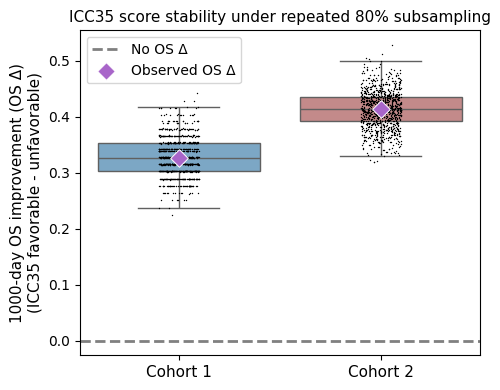

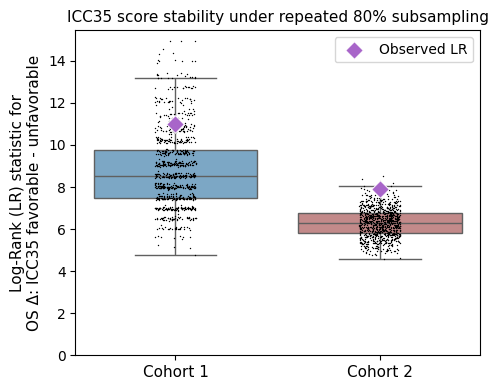

In [117]:
# OS delta:
palette_selected = {
    'Cohort 1':"#70a9d1",
    'Cohort 2': "#cc8080"
}
true_delta_highlight = 'as_dot'
# 'as_line' / 'as_dot'

plt.figure(figsize=(5, 4))
sns.boxplot(
    data=plot_df,
    x='Cohort',
    y='delta_S_good_minus_bad',
    showfliers = False,
    hue = 'Cohort',
    palette=palette_selected,
    legend = False
)
sns.stripplot(
    # data=plot_df.sample(500, random_state=42),  # optional downsample for display
    data=plot_df,
    x='Cohort',
    y='delta_S_good_minus_bad',
    color='black',
    alpha=1,
    size=1,
    legend = False
)

plt.axhline(0, linestyle='--', linewidth=2, color='grey', label = 'No OS Δ')
if true_delta_highlight == 'as_dot':
    observed_delta_df = pd.DataFrame({"Cohort": ["Cohort 1", "Cohort 2"],"delta_S_good_minus_bad": [true_c1_OS_delta,true_c2_OS_delta]})
    sns.scatterplot(data=observed_delta_df,
                    x="Cohort",y="delta_S_good_minus_bad",color="#A865C9",
                    s=80,marker="D",zorder=10,label="Observed OS Δ")
elif true_delta_highlight == 'as_line':
    plt.axhline(true_c1_OS_delta, xmin = 0.025, xmax = 0.475, linestyle = '--', linewidth = 2, color = "#1f77b4", label = 'Observed OS Δ, Cohort 1')
    plt.axhline(true_c2_OS_delta, xmin = 0.525, xmax = 0.975, linestyle = '--', linewidth = 2, color = "#d62728", label = 'Observed OS Δ, Cohort 2')
# plt.ylabel(f'Overall survival improvement (OS Δ)\nat {os_difference_time} days post alloHCT sampling\n(ICC35 favorable - ICC35 unfavorable)', fontsize = 11)

plt.ylabel(f'{os_difference_time}-day OS improvement (OS Δ)\n(ICC35 favorable - unfavorable)', fontsize = 11)
plt.xlabel('')
plt.title('ICC35 score stability under repeated 80% subsampling', fontsize = 11)
plt.xticks(fontsize = 11)
plt.legend()
plt.tight_layout()
plt.savefig(f'{base_dir}/OSdelta_StratBy{stratified_method}.pdf', bbox_inches = 'tight')
plt.show()




# Log-rank statistic:
palette_selected = {
    'Cohort 1':"#70a9d1",
    'Cohort 2': "#cc8080"
}
true_delta_highlight = 'as_dot'
# 'as_line' / 'as_dot'

plt.figure(figsize=(5, 4))
sns.boxplot(
    data=plot_df,
    x='Cohort',
    y='logrank_statistic',
    showfliers = False,
    hue = 'Cohort',
    palette=palette_selected,
    legend = False
)
sns.stripplot(
    # data=plot_df.sample(500, random_state=42),  # optional downsample for display
    data=plot_df,
    x='Cohort',
    y='logrank_statistic',
    color='black',
    alpha=1,
    size=1,
    legend = False
)

# plt.axhline(0, linestyle='--', linewidth=2, color='grey', label = 'No OS Δ')
if true_delta_highlight == 'as_dot':
    observed_delta_df = pd.DataFrame({"Cohort": ["Cohort 1", "Cohort 2"],"logrank_statistic": [true_c1_OS_LR,true_c2_OS_LR]})
    sns.scatterplot(data=observed_delta_df,
                    x="Cohort",y="logrank_statistic",color="#A865C9",
                    s=80,marker="D",zorder=10,label="Observed LR")
elif true_delta_highlight == 'as_line':
    plt.axhline(true_c1_OS_LR, xmin = 0.025, xmax = 0.475, linestyle = '--', linewidth = 2, color = "#1f77b4", label = 'Observed LR, Cohort 1')
    plt.axhline(true_c2_OS_LR, xmin = 0.525, xmax = 0.975, linestyle = '--', linewidth = 2, color = "#d62728", label = 'Observed LR, Cohort 2')
plt.ylim(bottom=0)

plt.ylabel('Log-Rank (LR) statistic for\nOS Δ: ICC35 favorable - unfavorable', fontsize = 11)
plt.xlabel('')
plt.title('ICC35 score stability under repeated 80% subsampling', fontsize = 11)
plt.xticks(fontsize = 11)
plt.legend()
plt.tight_layout()
plt.savefig(f'{base_dir}/LogRankStatistic_StratBy{stratified_method}.pdf', bbox_inches = 'tight')
plt.show()


<br></br>
<br></br>
<br></br>
*Permutation test:*

In [118]:
event_col = OUTCOME_COLS['OS']['event']
time_col = OUTCOME_COLS['OS']['time']
columns_to_keep = ['GvLhi_GvHDlo',event_col,time_col]
score_col = "GvLhi_GvHDlo"   # 1 = good/favorable, 0 = bad/other

In [119]:
def logrank_score_test(df, time_col, event_col, score_col, timepoint=None):
    """
    Calculates:
    - log-rank test statistic
    - log-rank p-value
    - optional fixed-time KM survival difference
    """
    good = df[df[score_col] == 1]
    bad = df[df[score_col] == 0]

    lr = logrank_test(
        durations_A=good[time_col],
        durations_B=bad[time_col],
        event_observed_A=good[event_col],
        event_observed_B=bad[event_col]
    )

    out = {
        "logrank_statistic": lr.test_statistic,
        "logrank_p": lr.p_value,
        "n_good": len(good),
        "n_bad": len(bad),
        "events_good": good[event_col].sum(),
        "events_bad": bad[event_col].sum()
    }

    if timepoint is not None:
        delta_s, s_good, s_bad = km_survival_at_time(
            df=df,
            time_col=time_col,
            event_col=event_col,
            score_col=score_col,
            timepoint=timepoint
        )

        out.update({
            "timepoint": timepoint,
            "S_good": s_good,
            "S_bad": s_bad,
            "delta_S_good_minus_bad": delta_s
        })

    return out

def permutation_logrank_test(
    df,
    time_col,
    event_col,
    score_col,
    n_iter=10000,
    timepoint=None,
    seed=42
):
    """
    Permutation test:
    randomly shuffles score labels while preserving the number of good-score patients.
    """

    df = df[[time_col, event_col, score_col]].dropna().copy()
    rng = np.random.default_rng(seed)

    # Observed result
    observed = logrank_score_test(
        df=df,
        time_col=time_col,
        event_col=event_col,
        score_col=score_col,
        timepoint=timepoint
    )

    observed_stat = observed["logrank_statistic"]

    perm_results = []

    original_scores = df[score_col].values.copy()

    for i in tqdm(range(n_iter)):
        shuffled_scores = rng.permutation(original_scores)

        perm_df = df.copy()
        perm_df[score_col] = shuffled_scores

        perm_out = logrank_score_test(
            df=perm_df,
            time_col=time_col,
            event_col=event_col,
            score_col=score_col,
            timepoint=timepoint
        )

        perm_out["iteration"] = i
        perm_results.append(perm_out)

    perm_results = pd.DataFrame(perm_results)

    # Empirical permutation p-value
    # log-rank statistic is always positive, so compare >= observed statistic
    empirical_p = (
        (perm_results["logrank_statistic"] >= observed_stat).sum() + 1
    ) / (n_iter + 1)

    observed = pd.Series(observed)
    observed["empirical_permutation_p"] = empirical_p
    observed["n_permutations"] = n_iter

    return observed, perm_results

In [120]:
print('Cohort 1')
observed_c1, perm_c1 = permutation_logrank_test(
    df=df_multivariate_OC[columns_to_keep].copy(),
    time_col=time_col,
    event_col=event_col,
    score_col=score_col,
    n_iter=10000,
    timepoint=os_difference_time,
    seed=42
)
print('Cohort 2')
observed_c2, perm_c2 = permutation_logrank_test(
    df=df_multivariate_VC[columns_to_keep].copy(),
    time_col=time_col,
    event_col=event_col,
    score_col=score_col,
    n_iter=10000,
    timepoint=os_difference_time,
    seed=43
)

Cohort 1


  0%|          | 0/10000 [00:00<?, ?it/s]

Cohort 2


  0%|          | 0/10000 [00:00<?, ?it/s]

In [122]:
base_dir = f'/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/SCRIPTS/Biomarker_Analysis/251102_NewStoryLine/FinalPlotsPaper/260625_Permutation_Subsampling/PermutationResults/Measured_At_{os_difference_time}days'
Path(base_dir).mkdir(parents=True, exist_ok=True)
perm_c1.to_excel(f'{base_dir}/Permutation_Cohort1.xlsx')
perm_c2.to_excel(f'{base_dir}/Permutation_Cohort2.xlsx')

In [125]:
observed_c2

logrank_statistic              7.917298
logrank_p                      0.004896
n_good                        20.000000
n_bad                        103.000000
events_good                    0.000000
events_bad                    32.000000
timepoint                   1000.000000
S_good                         0.585514
S_bad                          0.414486
delta_S_good_minus_bad         1.000000
empirical_permutation_p        0.008999
n_permutations             10000.000000
dtype: float64

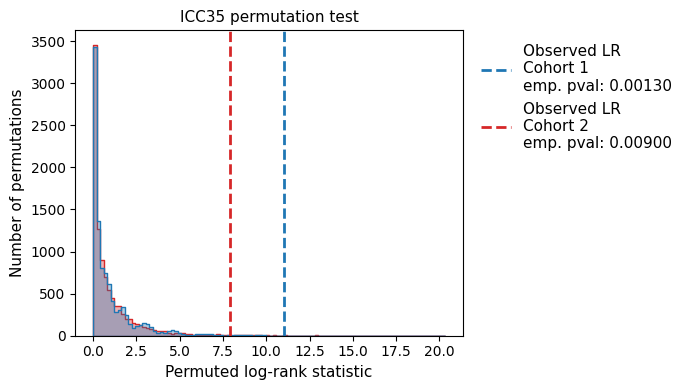

In [123]:
perm_plot_df = pd.concat([
    perm_c1.assign(Cohort="Cohort 1"),
    perm_c2.assign(Cohort="Cohort 2")
], ignore_index=True)

def plot_permutation_distribution_combined(
    perm_plot_df,
    observed_c1,
    observed_c2,
    title=None,
    save_path=None,
    palette=None,
):
    if palette is None:
        palette = {
            "Cohort 1": "#1f77b4",
            "Cohort 2": "#d62728"
        }

    fig, ax = plt.subplots(figsize=(7, 4))

    sns.histplot(
        data=perm_plot_df,
        x="logrank_statistic",
        hue="Cohort",
        bins=100,
        stat="count",
        element="step",
        common_norm=False,
        alpha=0.35,
        palette=palette,
        ax=ax
    )

    ax.axvline(
        observed_c1["logrank_statistic"],
        color=palette["Cohort 1"],
        linestyle="--",
        linewidth=2,
        label=f"Observed LR\nCohort 1\nemp. pval: {observed_c1['empirical_permutation_p']:.5f}"
    )

    ax.axvline(
        observed_c2["logrank_statistic"],
        color=palette["Cohort 2"],
        linestyle="--",
        linewidth=2,
        label=f"Observed LR\nCohort 2\nemp. pval: {observed_c2['empirical_permutation_p']:.5f}"
    )

    ax.set_xlabel("Permuted log-rank statistic", fontsize = 11)
    ax.set_ylabel("Number of permutations", fontsize = 11)

    if title is not None:
        ax.set_title(title, fontsize = 11)

    ax.legend(frameon=False, fontsize = 11, bbox_to_anchor = (1.01,1), loc = "upper left")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches = 'tight')
    plt.show()

base_dir = f'/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/SCRIPTS/Biomarker_Analysis/251102_NewStoryLine/FinalPlotsPaper/260625_Permutation_Subsampling/PermutationResults/Measured_At_{os_difference_time}days'
plot_permutation_distribution_combined(
    perm_plot_df=perm_plot_df,
    observed_c1=observed_c1,
    observed_c2=observed_c2,
    title="ICC35 permutation test",
    save_path = f'{base_dir}/LogRankStatistic_Permutation.pdf'
)
